In [71]:
import sys
sys.path.append("../utils/py")

import miniramses as ram

In [87]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import argparse
import miniramses as ram

prefix = 'grav'
path = '/home/jl4415/mini-ramses/'
nout = '4'

center=np.array([600,600,600])
log0=None

if prefix==None:
    prefix="hydro"
if path==None:
    path="./"
else:
    path=path+"/"
if prefix=="hydro":
    isort=0
if prefix=="peak":
    isort=1
if prefix=="grav":
    isort=0
if prefix=="rt":
    isort=0

print("Reading output number ",nout)


def compare(nout, nout_base):
    nout = str(nout)
    nout_base = str(nout_base)
    c=ram.rd_cell(nout,path=path,prefix=prefix,center=center)
    i=ram.rd_info(nout,path=path)
    c_base=ram.rd_cell(nout_base,path=path,prefix=prefix,center=center)
    i_base=ram.rd_info(nout_base,path=path)
    ii=1; jj=2
    mask = np.abs(c.x[2] - 600)<10
    ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask]-c_base.g[0][mask],sort=c.g[0][mask]-c_base.g[0][mask], cmap='magma')
    print(np.median((c.g[0][mask]-c_base.g[0][mask])/c_base.g[0][mask]))
    return c.g[0][mask]-c_base.g[0][mask]
    
def plot(nout, grid=True):
    ii=1; jj=2
    nout = str(nout)
    c=ram.rd_cell(nout,path=path,prefix=prefix,center=center)
    i=ram.rd_info(nout,path=path)
    mask = np.abs(c.x[2] - 600)<10
    if grid:
        ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask],sort=c.g[0][mask], cmap='magma', grid=grid)
    else:
        ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask],sort=c.g[0][mask], cmap='magma')

Reading output number  4


In [88]:
#nout =  '3'  # fmm (7,8)
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
min= -5314.3828125  max= 149.65234375
0.0021555925315526626


array([  28.69335938,  -67.90234375,  -68.65820312, ..., -188.46875   ,
       -225.18554688, -231.38867188])

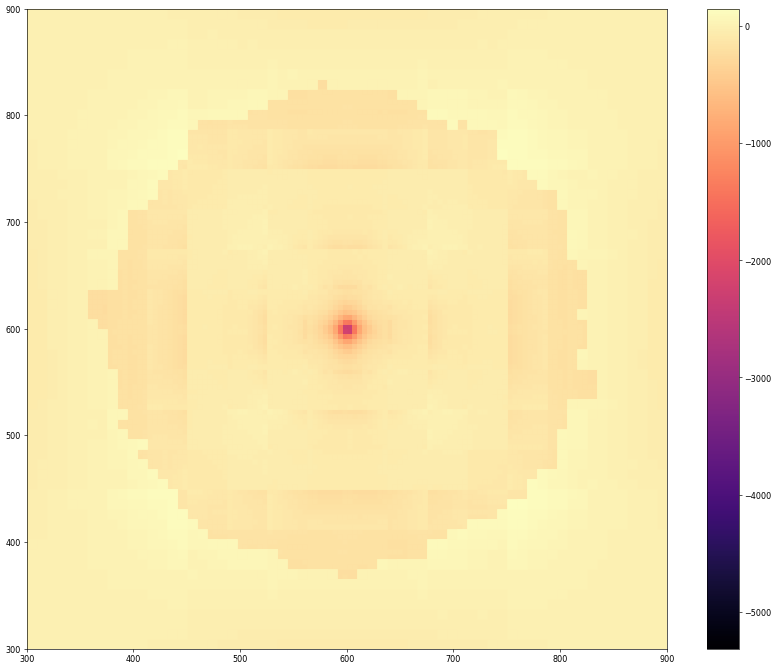

In [89]:
compare(4,3)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
min= -5267.96875  max= 71.765625
0.00046469877878892445


array([-58.86523438, -51.3984375 , -51.65820312, ..., -48.17578125,
       -48.57226562, -55.1875    ])

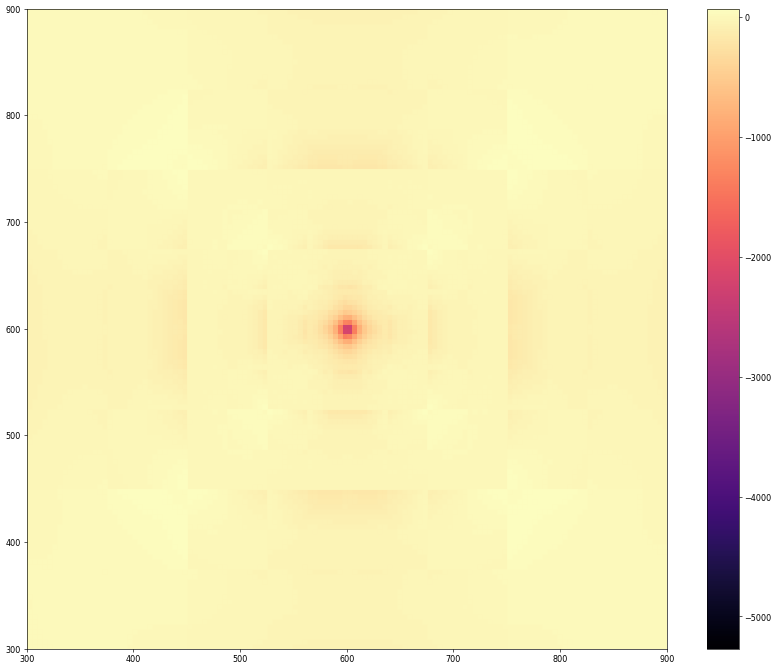

In [90]:
compare(5,6)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
min= -121564.234375  max= -13233.9013671875


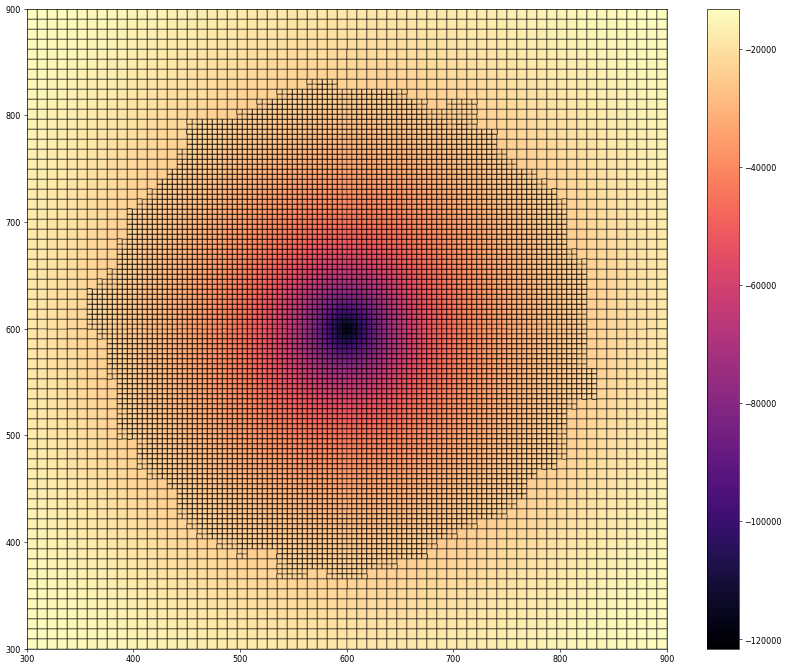

In [91]:
plot(3)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
min= -121564.234375  max= -13233.9013671875


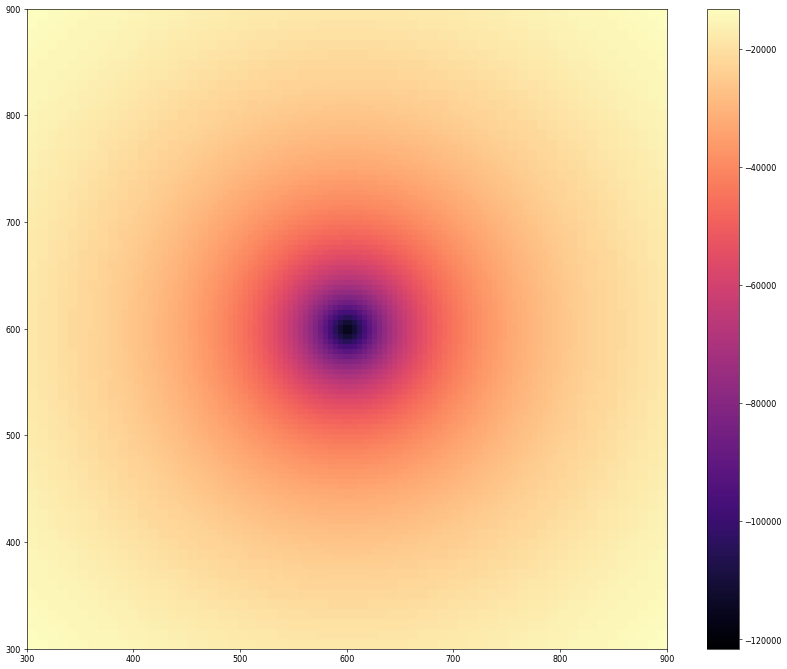

In [92]:
plot(3, False)

In [33]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.127       1.0    refine                  \n       2.844      21.4    rho                     \n       7.502      56.4    poisson                 \n       2.797      21.0    particle - kickdrift    \n       0.030       0.2    time step               \n      13.300     100.0    TOTAL\n'

In [34]:
#output4 as mg's output2
#output2 as fmm's output2

'''
     seconds         %    STEP
       0.071       0.5    refine                  
       3.213      22.7    rho                     
       8.663      61.1    poisson                 
       0.139       1.0    grav force              
       2.021      14.3    particle - kickdrift    
       0.034       0.2    time step               
       0.028       0.2    recursive call          
      14.170     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.071       0.5    refine                  \n       3.213      22.7    rho                     \n       8.663      61.1    poisson                 \n       0.139       1.0    grav force              \n       2.021      14.3    particle - kickdrift    \n       0.034       0.2    time step               \n       0.028       0.2    recursive call          \n      14.170     100.0    TOTAL\n'